# Single-Output GRU Baseline (SIS-only and OHS-only)

This notebook trains **two independent single-output GRU models** — one for SIS and one for OHS — using the same architecture and hyperparameters as `FINALLLL_gru_shap_selected_features_archive.ipynb`. It provides the baseline requested by the reviewer: a direct comparison of single-task vs multi-task (multi-output) performance.

**Key differences from the multi-output model:**
- Each model uses only its own task-specific SHAP features (`sis_sensor_top` for SIS, `ohs_sensor_top` for OHS) — no union
- One `FeatureGate`, one `DecayAttention`, and one prediction head per model
- Input projection is `Linear(n_features, hidden_dim)` (not `Linear(n_features, hidden_dim)` from concatenated gates)
- Loss is `SmoothL1Loss` on the single task's items only — no multi-task coupling

Everything else (GRU encoder, normalization, train/val/test split, evaluation metrics, calibration) is identical to the archive notebook.

In [1]:
from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

TOP_X_SENSOR = 23
TOP_Y_DEMO   = 0

SEED         = 42
FORECAST_GAP = 7
BATCH_SIZE   = 12
MAX_EPOCHS   = 500
PATIENCE     = 45
LR           = 2e-3
WEIGHT_DECAY = 1e-3
HIDDEN_DIM   = 24
DROPOUT      = 0.3
DECAY_RATE   = 0.08

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path.cwd()
SHAP_DIR = DATA_DIR / "catboost-shap"

sis_targets = [f"sis-{i:02d}" for i in range(1, 7)]
ohs_targets = [f"ohs-{i:02d}" for i in range(1, 13)]

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
plt.style.use("ggplot")
print(f"Device: {DEVICE}")
print(f"TOP_X_SENSOR={TOP_X_SENSOR}, TOP_Y_DEMO={TOP_Y_DEMO}")


Device: cpu
TOP_X_SENSOR=23, TOP_Y_DEMO=0


## Task Definitions

Each task uses only its own SHAP-ranked features. `sis_task` and `ohs_task` are dictionaries that bundle all task-specific information (feature lists, gate prior, target key, item names) and are passed through the pipeline to avoid any sharing between the two models.

In [2]:
def build_gate_prior(
    sensor_csv:  Path,
    demo_csv:    Path,
    sensor_cols: list,
    demo_cols:   list,
    floor:       float = 0.02,
) -> np.ndarray:
    sensor_shap  = pd.read_csv(sensor_csv).set_index("feature")["weights"].to_dict()
    sensor_prior = np.array([sensor_shap.get(c, floor) for c in sensor_cols], dtype=np.float32)
    demo_shap    = pd.read_csv(demo_csv).set_index("feature")["weights"].to_dict()
    demo_prior   = np.array([demo_shap.get(c, floor) for c in demo_cols], dtype=np.float32)
    combined     = np.concatenate([sensor_prior, demo_prior])
    return (combined / combined.mean()).astype(np.float32)

sis_sensor_cols = pd.read_csv(SHAP_DIR / "shap_catboost_sis_feature_importance.csv")["feature"].iloc[:TOP_X_SENSOR].tolist()
sis_demo_cols   = pd.read_csv(SHAP_DIR / "shap_catboost_demo_sis_feature_importance.csv")["feature"].iloc[:TOP_Y_DEMO].tolist()
ohs_sensor_cols = pd.read_csv(SHAP_DIR / "shap_catboost_ohs_feature_importance.csv")["feature"].iloc[:TOP_X_SENSOR].tolist()
ohs_demo_cols   = pd.read_csv(SHAP_DIR / "shap_catboost_demo_ohs_feature_importance.csv")["feature"].iloc[:TOP_Y_DEMO].tolist()

sis_gate_prior = build_gate_prior(
    SHAP_DIR / "shap_catboost_sis_feature_importance.csv",
    SHAP_DIR / "shap_catboost_demo_sis_feature_importance.csv",
    sis_sensor_cols, sis_demo_cols,
)
ohs_gate_prior = build_gate_prior(
    SHAP_DIR / "shap_catboost_ohs_feature_importance.csv",
    SHAP_DIR / "shap_catboost_demo_ohs_feature_importance.csv",
    ohs_sensor_cols, ohs_demo_cols,
)

sis_task = {
    "name"       : "SIS",
    "sensor_cols": sis_sensor_cols,
    "demo_cols"  : sis_demo_cols,
    "n_features" : len(sis_sensor_cols) + len(sis_demo_cols),
    "gate_prior" : sis_gate_prior,
    "target_key" : "sis",
    "items"      : sis_targets,
    "n_items"    : len(sis_targets),
}
ohs_task = {
    "name"       : "OHS",
    "sensor_cols": ohs_sensor_cols,
    "demo_cols"  : ohs_demo_cols,
    "n_features" : len(ohs_sensor_cols) + len(ohs_demo_cols),
    "gate_prior" : ohs_gate_prior,
    "target_key" : "ohs",
    "items"      : ohs_targets,
    "n_items"    : len(ohs_targets),
}

print(f"SIS task: {sis_task['n_features']} input features, {sis_task['n_items']} output items")
print(f"  sensor: {sis_sensor_cols}")
print(f"  demo  : {sis_demo_cols}")
print()
print(f"OHS task: {ohs_task['n_features']} input features, {ohs_task['n_items']} output items")
print(f"  sensor: {ohs_sensor_cols}")
print(f"  demo  : {ohs_demo_cols}")


SIS task: 23 input features, 6 output items
  sensor: ['sleep-snoring', 'acceleration-minutes-with-data', 'step-count', 'acceleration-movement-events-00to06', 'acceleration-mean', 'sleep-duration-to-wakeup', 'sleep-deep', 'heartrate-min', 'sleep-duration-to-sleep', 'acceleration-movement-events-18to24', 'acceleration-hours-with-data', 'sleep-heartrate-max', 'motion-ratio', 'sleep-heartrate-mean', 'sleep-light', 'acceleration-std', 'motion-max-timestamp', 'motion-count', 'motion-mean', 'step-mean', 'acceleration-coefficient-of-variation', 'acceleration-movement-events-06to12', 'heartrate-mean']
  demo  : []

OHS task: 23 input features, 12 output items
  sensor: ['acceleration-mean', 'acceleration-movement-events-00to06', 'motion-mean', 'sleep-deep', 'acceleration-movement-events-06to12', 'acceleration-movement-events-18to24', 'step-mean', 'sleep-snoring', 'heartrate-mean', 'sleep-heartrate-mean', 'motion-count', 'sleep-duration-to-sleep', 'sleep-duration-to-wakeup', 'step-max', 'heartr

## Data Loading

In [3]:
raw = pd.read_csv(
    DATA_DIR / "data" / "maison-llf-features.csv",
    parse_dates=["timestamp", "clinical-timestamp"]
).sort_values(["participant", "timestamp", "clinical-timestamp"]).reset_index(drop=True)

id_cols       = ["participant", "timestamp", "clinical-timestamp"]
clinical_cols = (
    ["sis", "ohs", "oks", "tug", "chairstand"]
    + [f"sis-{i:02d}" for i in range(1, 7)]
    + [f"ohs-{i:02d}" for i in range(1, 13)]
    + [f"oks-{i:02d}" for i in range(1, 13)]
)
sensor_cols_all = [c for c in raw.columns if c not in id_cols + clinical_cols]

demo_raw     = pd.read_csv(DATA_DIR / "data" / "maison-llf-demographics.csv")
demo_encoded = demo_raw.copy()
label_maps   = {}
for col in [c for c in demo_raw.columns if c != "participant" and not pd.api.types.is_numeric_dtype(demo_raw[c])]:
    cats    = sorted(demo_raw[col].dropna().unique())
    mapping = {c: float(i) for i, c in enumerate(cats)}
    demo_encoded[col] = demo_raw[col].map(mapping)
    label_maps[col]   = mapping
for col in [c for c in demo_raw.columns if c != "participant" and pd.api.types.is_numeric_dtype(demo_raw[c])]:
    demo_encoded[col] = demo_raw[col].astype(float)
demo_lookup = demo_encoded.set_index("participant").astype(float)

print(f"Features CSV: {len(raw)} rows, {raw['participant'].nunique()} patients")
print(f"All sensor columns ({len(sensor_cols_all)})")
print(f"Demographic columns: {demo_lookup.columns.tolist()}")


Features CSV: 1008 rows, 18 patients
All sensor columns (46)
Demographic columns: ['sex', 'age', 'fracture-type', 'relationship', 'education', 'work', 'ethnicity']


## Build Temporal Examples

One example per (patient, clinical assessment) pair. The full sensor history up to `FORECAST_GAP` days before the assessment is stored. Both SIS and OHS item targets are kept in every example so that either task can access them.

In [4]:
def build_forecast_examples(features_df: pd.DataFrame, demo_lkp: pd.DataFrame, gap_days: int) -> list:
    examples = []
    for patient, pdf in features_df.groupby("participant", sort=True):
        pdf      = pdf.sort_values("timestamp")
        demo_row = demo_lkp.loc[patient].to_dict()
        for clinical_time, assess_rows in pdf.groupby("clinical-timestamp", sort=True):
            cutoff  = clinical_time - pd.Timedelta(days=gap_days)
            history = pdf.loc[pdf["timestamp"] <= cutoff].copy()
            if history.empty:
                continue
            tr = assess_rows.iloc[0]
            examples.append({
                "patient"        : int(patient),
                "clinical_time"  : clinical_time,
                "cutoff"         : cutoff,
                "timestamps"     : history["timestamp"].to_numpy(),
                "x_sensor_frame" : history[sensor_cols_all].copy(),
                "demo_values"    : demo_row,
                "sis"            : tr[sis_targets].astype(float).to_numpy(),
                "ohs"            : tr[ohs_targets].astype(float).to_numpy(),
                "sis_total"      : float(tr["sis"]),
                "ohs_total"      : float(tr["ohs"]),
            })
    return examples

examples      = build_forecast_examples(raw, demo_lookup, FORECAST_GAP)
example_index = pd.DataFrame([{
    "patient"      : e["patient"],
    "clinical_time": e["clinical_time"],
    "history_days" : len(e["timestamps"]),
} for e in examples])

assert len(examples) == raw["participant"].nunique() * 4
print(f"Total examples: {len(examples)} (18 patients × 4 assessments)")
print(example_index.head(8).to_string(index=False))


Total examples: 72 (18 patients × 4 assessments)
 patient clinical_time  history_days
       1    2022-04-13             7
       1    2022-04-27            21
       1    2022-05-11            35
       1    2022-05-25            49
       2    2022-10-28             7
       2    2022-11-11            21
       2    2022-11-25            35
       2    2022-12-09            49


## Train / Val / Test Split

Identical 12 / 3 / 3 patient split with seed=42 as in the multi-output archive notebook.

In [ ]:
all_patients = np.array(sorted(example_index["patient"].unique()))

test_pts = np.array([15, 6, 7])

remaining_pts = np.setdiff1d(all_patients, test_pts)

rng = np.random.default_rng(SEED)
rng.shuffle(remaining_pts)

train_pts = remaining_pts[:12]
val_pts   = remaining_pts[12:]

def example_ids_for(patients) -> np.ndarray:
    return np.flatnonzero(example_index["patient"].isin(patients).to_numpy())

def patients_of(ids) -> list:
    return sorted(example_index.iloc[ids]["patient"].unique().tolist())

split = {
    "train_ids": example_ids_for(train_pts),
    "val_ids": example_ids_for(val_pts),
    "test_ids": example_ids_for(test_pts),
    "train_patients": train_pts.tolist(),
}

display(pd.DataFrame([
    {
        "split": "train",
        "patients": sorted(train_pts.tolist()),
        "n_examples": len(split["train_ids"])
    },
    {
        "split": "val",
        "patients": sorted(val_pts.tolist()),
        "n_examples": len(split["val_ids"])
    },
    {
        "split": "test",
        "patients": sorted(test_pts.tolist()),
        "n_examples": len(split["test_ids"])
    },
]))


,split,patients,n_examples
0,train,"[1, 4, 6, 7, 8, 10, 11, 12, 13, 15, 17, 18]",48
1,val,"[3, 5, 16]",12
2,test,"[2, 9, 14]",12


## Normalization and Dataset

All statistics are fit on training data only. The `TaskForecastDataset` and `make_collate_fn` are parameterized so that the SIS and OHS models use entirely separate normalization and feature views of the same raw examples.

In [6]:
def compute_sensor_stats(train_ids: np.ndarray, sensor_cols: list) -> dict:
    frames  = pd.concat(
        [examples[i]["x_sensor_frame"].reindex(columns=sensor_cols) for i in train_ids],
        ignore_index=True,
    )
    median  = frames.median(numeric_only=True)
    imputed = frames.fillna(median)
    mean    = imputed.mean()
    std     = imputed.std(ddof=0).replace(0, 1.0).fillna(1.0)
    return {"median": median, "mean": mean, "std": std}

def compute_demo_stats(train_patients: list, demo_cols: list) -> dict:
    dt   = demo_lookup.loc[demo_lookup.index.isin(train_patients), demo_cols]
    mean = dt.mean()
    std  = dt.std(ddof=0).replace(0, 1.0).fillna(1.0)
    return {"mean": mean, "std": std}

def transform_inputs(example: dict, sensor_cols: list, demo_cols: list,
                     sensor_stats: dict, demo_stats: dict) -> np.ndarray:
    T      = len(example["timestamps"])
    s_df   = example["x_sensor_frame"].reindex(columns=sensor_cols).fillna(sensor_stats["median"])
    s_norm = ((s_df - sensor_stats["mean"]) / sensor_stats["std"]).astype(np.float32).to_numpy()
    d_vals  = np.array([example["demo_values"][c] for c in demo_cols], dtype=np.float32)
    d_norm  = ((d_vals - demo_stats["mean"].to_numpy()) / demo_stats["std"].to_numpy()).astype(np.float32)
    d_tiled = np.tile(d_norm, (T, 1))
    return np.concatenate([s_norm, d_tiled], axis=1)

class TaskForecastDataset(Dataset):
    def __init__(self, records: list, ids: np.ndarray, task: dict,
                 sensor_stats: dict, demo_stats: dict):
        self.records      = [records[i] for i in ids]
        self.task         = task
        self.sensor_stats = sensor_stats
        self.demo_stats   = demo_stats

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        e = self.records[idx]
        x = transform_inputs(
            e, self.task["sensor_cols"], self.task["demo_cols"],
            self.sensor_stats, self.demo_stats,
        )
        return {
            "x"            : torch.tensor(x.tolist(), dtype=torch.float32),
            "y"            : torch.tensor(e[self.task["target_key"]].tolist(), dtype=torch.float32),
            "patient"      : e["patient"],
            "clinical_time": e["clinical_time"],
        }

def make_collate_fn(n_feat: int):
    def collate_fn(batch: list) -> dict:
        lengths = torch.tensor([len(b["x"]) for b in batch], dtype=torch.long)
        max_len = int(lengths.max())
        x    = torch.zeros(len(batch), max_len, n_feat, dtype=torch.float32)
        mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
        for i, b in enumerate(batch):
            L = int(lengths[i])
            x[i, :L]    = b["x"]
            mask[i, :L] = True
        return {
            "x"            : x,
            "mask"         : mask,
            "lengths"      : lengths,
            "y"            : torch.stack([b["y"] for b in batch]),
            "patient"      : [b["patient"]       for b in batch],
            "clinical_time": [b["clinical_time"]  for b in batch],
        }
    return collate_fn

def make_loader(ids: np.ndarray, task: dict, sensor_stats: dict,
                demo_stats: dict, shuffle: bool) -> DataLoader:
    return DataLoader(
        TaskForecastDataset(examples, ids, task, sensor_stats, demo_stats),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        collate_fn=make_collate_fn(task["n_features"]),
    )

_ss = compute_sensor_stats(split["train_ids"], sis_task["sensor_cols"])
_ds = compute_demo_stats(split["train_patients"], sis_task["demo_cols"])
_ldr = make_loader(split["train_ids"], sis_task, _ss, _ds, shuffle=True)
_b   = next(iter(_ldr))
print("SIS batch shapes:", {k: tuple(v.shape) for k, v in _b.items() if torch.is_tensor(v)})
del _ss, _ds, _ldr, _b


SIS batch shapes: {'x': (12, 49, 23), 'mask': (12, 49), 'lengths': (12,), 'y': (12, 6)}


## Model Architecture

`SingleOutputForecaster` is architecturally identical to the shared trunk of the multi-output model: one `FeatureGate` → `Linear(n_features, hidden_dim)` → `GRU` → `DecayAttention` → one prediction head. The only structural change is that the input projection takes `n_features` (not `n_features×2`) because there is only one gate, and there is one attention stream and one head instead of two.

In [7]:
def inverse_softplus(x: np.ndarray) -> torch.Tensor:
    t = torch.tensor(np.asarray(x).tolist(), dtype=torch.float32).clamp_min(1e-4)
    return torch.log(torch.expm1(t))

class FeatureGate(nn.Module):
    def __init__(self, prior: np.ndarray):
        super().__init__()
        self.raw = nn.Parameter(inverse_softplus(prior))

    def forward(self, x: torch.Tensor):
        weights = torch.nn.functional.softplus(self.raw)
        weights = weights / weights.mean().clamp_min(1e-6)
        return x * weights, weights

class DecayAttention(nn.Module):
    def __init__(self, hidden_dim: int, decay_rate: float):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
        self.raw_decay = nn.Parameter(
            inverse_softplus(np.array([decay_rate], dtype=np.float32))
        )

    def forward(self, encoded: torch.Tensor, mask: torch.Tensor, lengths: torch.Tensor):
        steps  = torch.arange(encoded.size(1), device=encoded.device).unsqueeze(0)
        age    = (lengths.to(encoded.device).unsqueeze(1) - 1 - steps).clamp_min(0).float()
        decay  = torch.nn.functional.softplus(self.raw_decay)
        logits = self.score(encoded).squeeze(-1) - decay * age
        logits = logits.masked_fill(~mask, -torch.finfo(encoded.dtype).max)
        attn   = torch.softmax(logits, dim=1)
        ctx    = torch.bmm(attn.unsqueeze(1), encoded).squeeze(1)
        return ctx, attn, decay

class SingleOutputForecaster(nn.Module):
    def __init__(self, n_features: int, gate_prior: np.ndarray, n_items: int,
                 hidden_dim: int, dropout: float, decay_rate: float):
        super().__init__()
        self.feature_gate = FeatureGate(gate_prior)
        self.input_projection = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.attention = DecayAttention(hidden_dim, decay_rate)
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_items),
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor, lengths: torch.Tensor) -> dict:
        gated_x, gate_w  = self.feature_gate(x)
        projected         = self.input_projection(gated_x)
        packed            = pack_padded_sequence(projected, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_enc, _     = self.gru(packed)
        encoded, _        = pad_packed_sequence(packed_enc, batch_first=True, total_length=x.size(1))
        ctx, attn, decay  = self.attention(encoded, mask, lengths)
        return {
            "pred"        : self.head(ctx),
            "attention"   : attn,
            "gate_weights": gate_w,
            "decay"       : decay,
        }

def make_model(task: dict) -> SingleOutputForecaster:
    return SingleOutputForecaster(
        task["n_features"], task["gate_prior"], task["n_items"],
        HIDDEN_DIM, DROPOUT, DECAY_RATE,
    ).to(DEVICE)

for task in [sis_task, ohs_task]:
    m = make_model(task)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{task['name']} model: {n_params:,} trainable parameters")
    del m


SIS model: 5,071 trainable parameters
OHS model: 5,221 trainable parameters


## Training

`SmoothL1Loss` on item scores, AdamW with gradient clipping, and early stopping on validation loss — identical to the multi-output archive. Each task is trained independently from scratch.

In [8]:
_loss_fn = nn.SmoothL1Loss()

def task_loss(output: dict, batch: dict) -> torch.Tensor:
    return _loss_fn(output["pred"], batch["y"])

def move_batch(batch: dict) -> dict:
    return {k: v.to(DEVICE) if torch.is_tensor(v) else v for k, v in batch.items()}

def run_epoch(model, optimizer, loader, training: bool) -> float:
    model.train(training)
    total, n = 0.0, 0
    for batch in loader:
        batch = move_batch(batch)
        with torch.set_grad_enabled(training):
            output = model(batch["x"], batch["mask"], batch["lengths"])
            loss   = task_loss(output, batch)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        total += loss.item() * len(batch["x"])
        n     += len(batch["x"])
    return total / n

def train_model(split: dict, task: dict) -> dict:
    seed_everything(SEED)
    sensor_stats = compute_sensor_stats(split["train_ids"], task["sensor_cols"])
    demo_stats   = compute_demo_stats(split["train_patients"], task["demo_cols"])
    train_loader = make_loader(split["train_ids"], task, sensor_stats, demo_stats, shuffle=True)
    val_loader   = make_loader(split["val_ids"],   task, sensor_stats, demo_stats, shuffle=False)
    model     = make_model(task)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best_val   = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait       = 0
    history    = []
    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_epoch(model, optimizer, train_loader, training=True)
        val_loss   = run_epoch(model, optimizer, val_loader,   training=False)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        if val_loss < best_val - 1e-5:
            best_val   = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait       = 0
        else:
            wait += 1
        if wait >= PATIENCE:
            break
    model.load_state_dict(best_state)
    decay = float(torch.nn.functional.softplus(model.attention.raw_decay.detach()))
    return {
        "model"       : model,
        "task"        : task,
        "sensor_stats": sensor_stats,
        "demo_stats"  : demo_stats,
        "train_ids"   : split["train_ids"],
        "val_ids"     : split["val_ids"],
        "test_ids"    : split["test_ids"],
        "history"     : pd.DataFrame(history),
        "best_val"    : best_val,
        "epochs"      : len(history),
        "decay"       : decay,
    }


## Train SIS Model

In [9]:
sis_artifact = train_model(split, sis_task)
print(
    f"SIS — epochs={sis_artifact['epochs']}, "
    f"best_val={sis_artifact['best_val']:.4f}, "
    f"decay={sis_artifact['decay']:.4f}"
)


SIS — epochs=78, best_val=0.2034, decay=0.0749


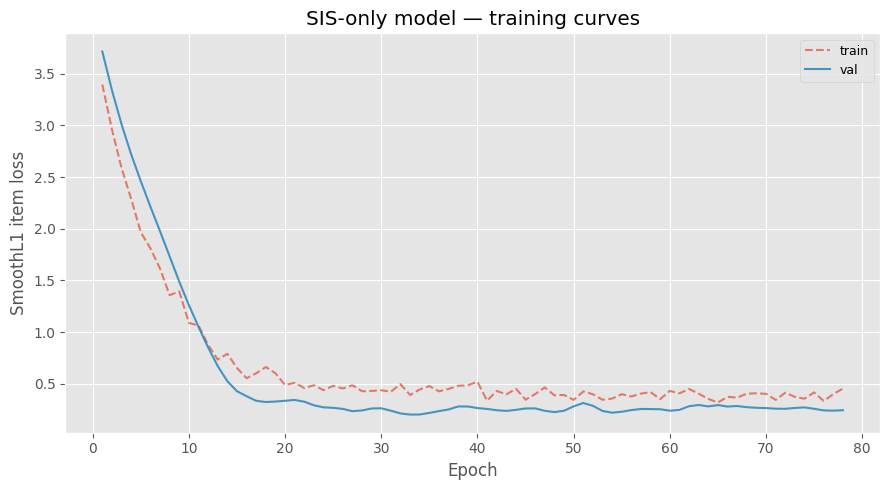

In [10]:
sis_hist = sis_artifact["history"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sis_hist["epoch"], sis_hist["train_loss"], linestyle="--", alpha=0.7, label="train")
ax.plot(sis_hist["epoch"], sis_hist["val_loss"],   alpha=0.9,              label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("SmoothL1 item loss")
ax.set_title("SIS-only model — training curves")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Train OHS Model

In [11]:
ohs_artifact = train_model(split, ohs_task)
print(
    f"OHS — epochs={ohs_artifact['epochs']}, "
    f"best_val={ohs_artifact['best_val']:.4f}, "
    f"decay={ohs_artifact['decay']:.4f}"
)


OHS — epochs=57, best_val=0.6836, decay=0.0787


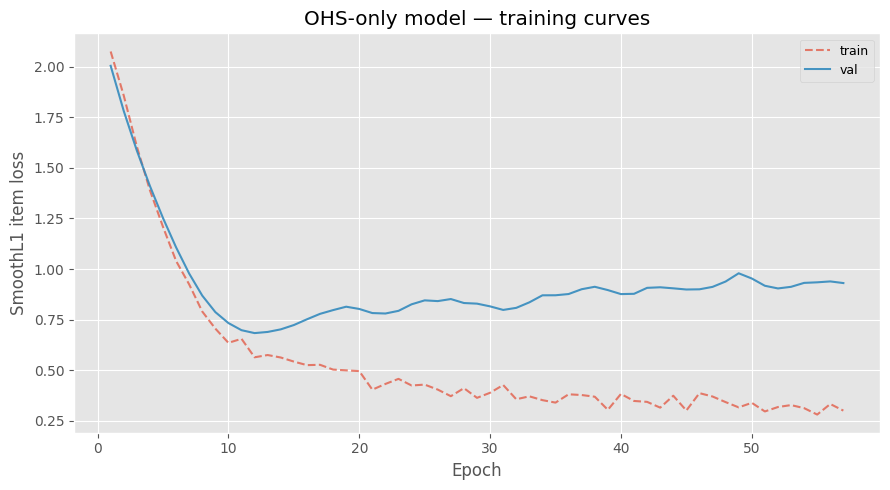

In [12]:
ohs_hist = ohs_artifact["history"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ohs_hist["epoch"], ohs_hist["train_loss"], linestyle="--", alpha=0.7, label="train")
ax.plot(ohs_hist["epoch"], ohs_hist["val_loss"],   alpha=0.9,              label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("SmoothL1 item loss")
ax.set_title("OHS-only model — training curves")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Evaluation

Identical evaluation protocol to the archive notebook: item-level metrics (MAE, RMSE, R², Pearson r), total-score metrics (raw and calibrated), per-patient breakdowns, and prediction-vs-truth scatter plots (train and test).

In [13]:
def collect_predictions(artifact: dict, ids: np.ndarray) -> pd.DataFrame:
    rows   = []
    model  = artifact["model"]
    task   = artifact["task"]
    model.eval()
    loader = make_loader(ids, task, artifact["sensor_stats"], artifact["demo_stats"], shuffle=False)
    with torch.no_grad():
        for batch in loader:
            dev_batch = move_batch(batch)
            output    = model(dev_batch["x"], dev_batch["mask"], dev_batch["lengths"])
            preds     = output["pred"].cpu().tolist()
            for i in range(len(batch["patient"])):
                base = {
                    "patient"      : batch["patient"][i],
                    "clinical_time": pd.Timestamp(batch["clinical_time"][i]),
                    "history_days" : int(batch["lengths"][i]),
                }
                for name, truth, pred in zip(task["items"], batch["y"][i].tolist(), preds[i]):
                    rows.append(base | {
                        "outcome"   : task["name"],
                        "item"      : name,
                        "truth"     : float(truth),
                        "prediction": float(pred),
                    })
    return pd.DataFrame(rows)

def regression_metrics(frame: pd.DataFrame) -> pd.Series:
    y, p     = frame["truth"].to_numpy(), frame["prediction"].to_numpy()
    pearson  = np.corrcoef(y, p)[0, 1] if (len(y) > 1 and np.std(y) > 0 and np.std(p) > 0) else np.nan
    residual = y - p
    sst      = np.square(y - y.mean()).sum()
    r2       = 1 - np.square(residual).sum() / sst if sst > 0 else np.nan
    return pd.Series({"n": len(frame), "MAE": np.abs(residual).mean(),
                      "RMSE": np.sqrt(np.square(residual).mean()), "R2": r2, "Pearson": pearson})

def grouped_metrics(frame: pd.DataFrame, group_cols: list) -> pd.DataFrame:
    rows = []
    for keys, group in frame.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        rows.append(dict(zip(group_cols, keys)) | regression_metrics(group).to_dict())
    return pd.DataFrame(rows).set_index(group_cols)

def totalize(frame: pd.DataFrame) -> pd.DataFrame:
    return frame.groupby(
        ["patient", "clinical_time", "history_days", "outcome"], as_index=False
    )[["truth", "prediction"]].sum()

def fit_calibration(frame: pd.DataFrame) -> dict:
    params = {}
    for outcome, sub in frame.groupby("outcome"):
        x    = sub["prediction"].to_numpy(dtype=float)
        y    = sub["truth"].to_numpy(dtype=float)
        xvar = np.var(x)
        if len(sub) < 3 or xvar <= 1e-8:
            slope, intercept = 1.0, 0.0
        else:
            slope     = float(np.clip(np.cov(x, y, ddof=0)[0, 1] / xvar, 0.25, 2.5))
            intercept = float(y.mean() - slope * x.mean())
        params[outcome] = {"slope": slope, "intercept": intercept}
    return params

def apply_calibration(frame: pd.DataFrame, params: dict) -> pd.DataFrame:
    out = frame.copy()
    for outcome, p in params.items():
        mask = out["outcome"] == outcome
        out.loc[mask, "prediction"] = p["slope"] * out.loc[mask, "prediction"] + p["intercept"]
    return out


## SIS Results

In [14]:
sis_train_preds = collect_predictions(sis_artifact, sis_artifact["train_ids"])
sis_val_preds   = collect_predictions(sis_artifact, sis_artifact["val_ids"])
sis_test_preds  = collect_predictions(sis_artifact, sis_artifact["test_ids"])

sis_train_total = totalize(sis_train_preds)
sis_val_total   = totalize(sis_val_preds)
sis_test_total  = totalize(sis_test_preds)

sis_cal_params    = fit_calibration(sis_val_total)
sis_test_cal      = apply_calibration(sis_test_total, sis_cal_params)

print("=== SIS per-item metrics (test) ===")
display(grouped_metrics(sis_test_preds, ["outcome"]))
display(grouped_metrics(sis_test_preds, ["item"]))

print("\n=== SIS total-score metrics ===")
print("train raw:")
display(grouped_metrics(sis_train_total, ["outcome"]))
print("test raw:")
display(grouped_metrics(sis_test_total, ["outcome"]))
print("test calibrated (from val):")
display(grouped_metrics(sis_test_cal, ["outcome"]))

print("\n=== SIS per-patient metrics (test) ===")
display(grouped_metrics(sis_test_preds, ["patient"]))


=== SIS per-item metrics (test) ===


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
SIS,72.0,0.907198,1.143001,-0.308724,0.157009


,n,MAE,RMSE,R2,Pearson
item,,,,,
sis-01,12.0,1.143501,1.307334,-0.922761,-0.625841
sis-02,12.0,0.472230,0.611536,-0.538644,-0.045837
sis-03,12.0,0.637090,0.763740,-0.166598,0.291275
sis-04,12.0,0.812841,1.178413,-0.868846,-0.440449
sis-05,12.0,1.347383,1.595085,-2.053154,-0.029878
sis-06,12.0,1.030142,1.113267,0.213795,0.563081



=== SIS total-score metrics ===
train raw:


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
SIS,48.0,1.344509,1.76663,0.813784,0.911693


...

,n,MAE,RMSE,R2,Pearson
outcome,,,,,
SIS,12.0,3.103068,4.025502,-0.67274,-0.208609


test calibrated (from val):


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
SIS,12.0,3.816771,4.871626,-1.449831,-0.208609



=== SIS per-patient metrics (test) ===


,n,MAE,RMSE,R2,Pearson
patient,,,,,
2,24.0,1.195240,1.495727,-1.459212,-0.245356
9,24.0,0.790564,0.948444,0.317341,0.581324
14,24.0,0.735789,0.884652,-1.561268,0.176782


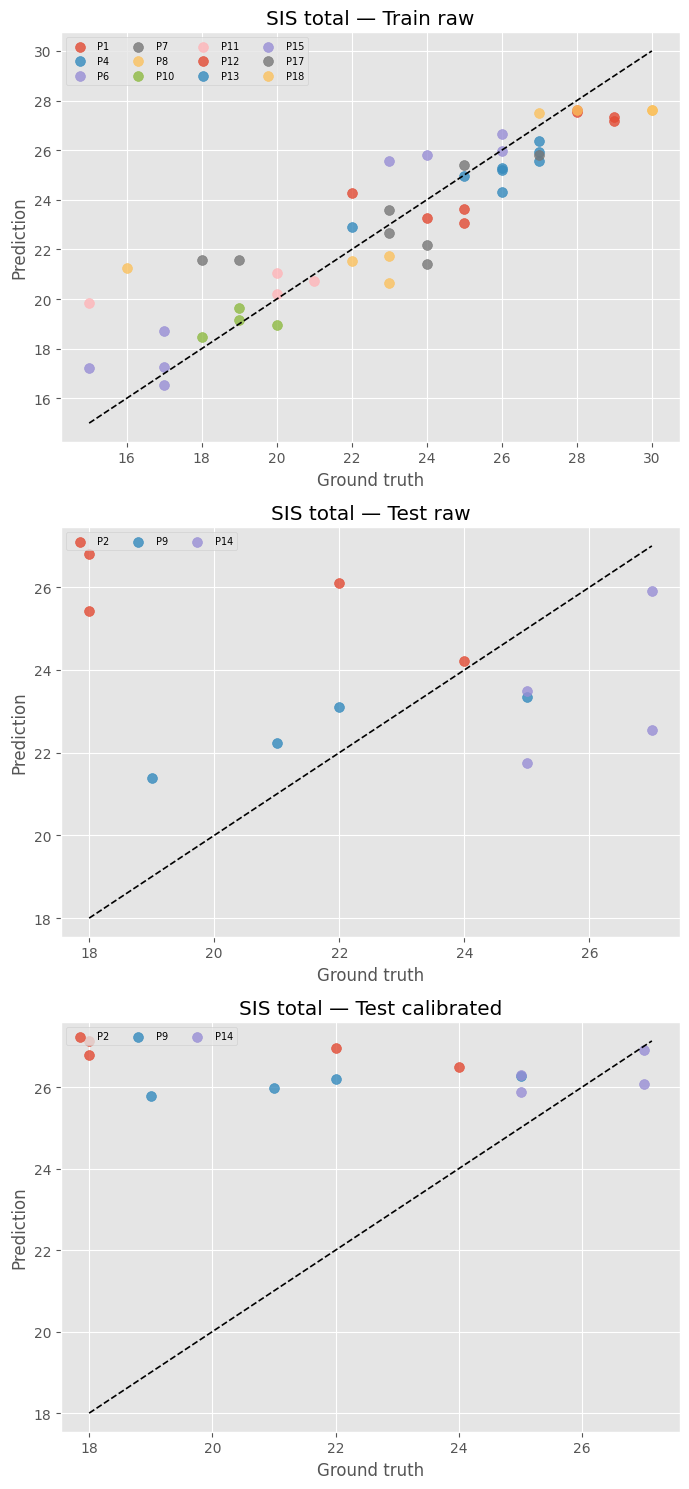

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(7, 15))
plot_frames_sis = [
    ("Train raw",        sis_train_total),
    ("Test raw",         sis_test_total),
    ("Test calibrated",  sis_test_cal),
]

for ax, (label, frame) in zip(axes, plot_frames_sis):
    sub = frame[frame["outcome"] == "SIS"]
    for patient, pf in sub.groupby("patient"):
        ax.scatter(pf["truth"], pf["prediction"], label=f"P{patient}", alpha=0.8, s=50)
    lo = min(sub["truth"].min(), sub["prediction"].min())
    hi = max(sub["truth"].max(), sub["prediction"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1.2, linestyle="--")
    ax.set_title(f"SIS total — {label}")
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("Prediction")
    ax.legend(fontsize=7, ncol=4, loc="upper left")

plt.tight_layout()
plt.show()


## OHS Results

In [16]:
ohs_train_preds = collect_predictions(ohs_artifact, ohs_artifact["train_ids"])
ohs_val_preds   = collect_predictions(ohs_artifact, ohs_artifact["val_ids"])
ohs_test_preds  = collect_predictions(ohs_artifact, ohs_artifact["test_ids"])

ohs_train_total = totalize(ohs_train_preds)
ohs_val_total   = totalize(ohs_val_preds)
ohs_test_total  = totalize(ohs_test_preds)

ohs_cal_params  = fit_calibration(ohs_val_total)
ohs_test_cal    = apply_calibration(ohs_test_total, ohs_cal_params)

print("=== OHS per-item metrics (test) ===")
display(grouped_metrics(ohs_test_preds, ["outcome"]))
display(grouped_metrics(ohs_test_preds, ["item"]))

print("\n=== OHS total-score metrics ===")
print("train raw:")
display(grouped_metrics(ohs_train_total, ["outcome"]))
print("test raw:")
display(grouped_metrics(ohs_test_total, ["outcome"]))
print("test calibrated (from val):")
display(grouped_metrics(ohs_test_cal, ["outcome"]))

print("\n=== OHS per-patient metrics (test) ===")
display(grouped_metrics(ohs_test_preds, ["patient"]))


=== OHS per-item metrics (test) ===


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,144.0,1.074651,1.295793,-0.448793,-0.119807


,n,MAE,RMSE,R2,Pearson
item,,,,,
ohs-01,12.0,1.166615,1.227919,-3.257276,0.476341
ohs-02,12.0,1.059633,1.229492,-5.046602,-0.434269
ohs-03,12.0,1.145569,1.245300,-2.784933,0.274719
ohs-04,12.0,0.984140,1.307532,-0.230940,-0.066363
ohs-05,12.0,1.149229,1.306802,-0.211396,0.299451
ohs-06,12.0,0.889724,0.977961,-0.187265,0.598519
ohs-07,12.0,0.967294,1.048713,-0.480104,0.594117
ohs-08,12.0,1.226242,1.348353,-3.437289,-0.148687
ohs-09,12.0,1.052339,1.128592,-1.183519,-0.297253



=== OHS total-score metrics ===
train raw:


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,48.0,5.389287,7.292557,0.090889,0.678809


...

,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,12.0,5.693307,6.499597,-1.236487,0.623405


test calibrated (from val):


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,12.0,9.611901,10.451917,-4.783431,0.623405



=== OHS per-patient metrics (test) ===


,n,MAE,RMSE,R2,Pearson
patient,,,,,
2,48.0,0.819485,1.010496,-0.783639,0.216921
9,48.0,1.402286,1.628628,-0.634010,-0.354906
14,48.0,1.002183,1.167778,-0.327409,-0.318257


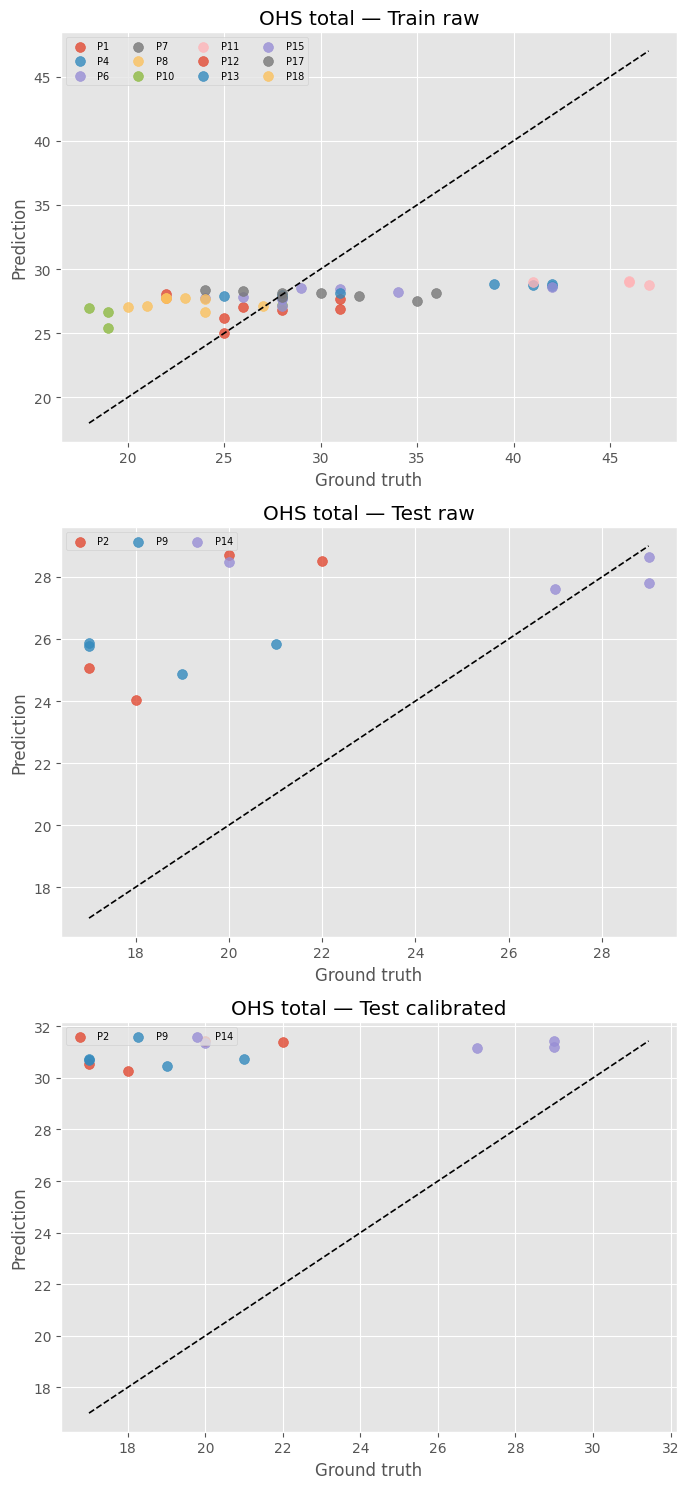

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(7, 15))
plot_frames_ohs = [
    ("Train raw",        ohs_train_total),
    ("Test raw",         ohs_test_total),
    ("Test calibrated",  ohs_test_cal),
]

for ax, (label, frame) in zip(axes, plot_frames_ohs):
    sub = frame[frame["outcome"] == "OHS"]
    for patient, pf in sub.groupby("patient"):
        ax.scatter(pf["truth"], pf["prediction"], label=f"P{patient}", alpha=0.8, s=50)
    lo = min(sub["truth"].min(), sub["prediction"].min())
    hi = max(sub["truth"].max(), sub["prediction"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1.2, linestyle="--")
    ax.set_title(f"OHS total — {label}")
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("Prediction")
    ax.legend(fontsize=7, ncol=4, loc="upper left")

plt.tight_layout()
plt.show()


## Single-Task vs Multi-Task Comparison

The table below consolidates single-task results for both outcomes in the same format as the multi-output archive notebook. Cross-reference the `outcome` row of the archive's "Overall per-item metrics" table to assess whether multi-tasking improved or degraded performance relative to the single-output baseline.

In [18]:
sis_overall = regression_metrics(sis_test_preds).rename("SIS (single-task, item-level)")
ohs_overall = regression_metrics(ohs_test_preds).rename("OHS (single-task, item-level)")

sis_total_m = regression_metrics(sis_test_total).rename("SIS (single-task, total raw)")
ohs_total_m = regression_metrics(ohs_test_total).rename("OHS (single-task, total raw)")

sis_total_cal_m = regression_metrics(sis_test_cal).rename("SIS (single-task, total calibrated)")
ohs_total_cal_m = regression_metrics(ohs_test_cal).rename("OHS (single-task, total calibrated)")

comparison = pd.concat([
    sis_overall, ohs_overall,
    sis_total_m, ohs_total_m,
    sis_total_cal_m, ohs_total_cal_m,
], axis=1).T[["MAE", "RMSE", "R2", "Pearson"]].round(3)

print("=== Single-task baseline — test set summary ===")
display(comparison)


=== Single-task baseline — test set summary ===


,MAE,RMSE,R2,Pearson
"SIS (single-task, item-level)",0.907,1.143,-0.309,0.157
"OHS (single-task, item-level)",1.075,1.296,-0.449,-0.120
"SIS (single-task, total raw)",3.103,4.026,-0.673,-0.209
"OHS (single-task, total raw)",5.693,6.500,-1.236,0.623
"SIS (single-task, total calibrated)",3.817,4.872,-1.450,-0.209
"OHS (single-task, total calibrated)",9.612,10.452,-4.783,0.623


## Learned Feature Gate Weights

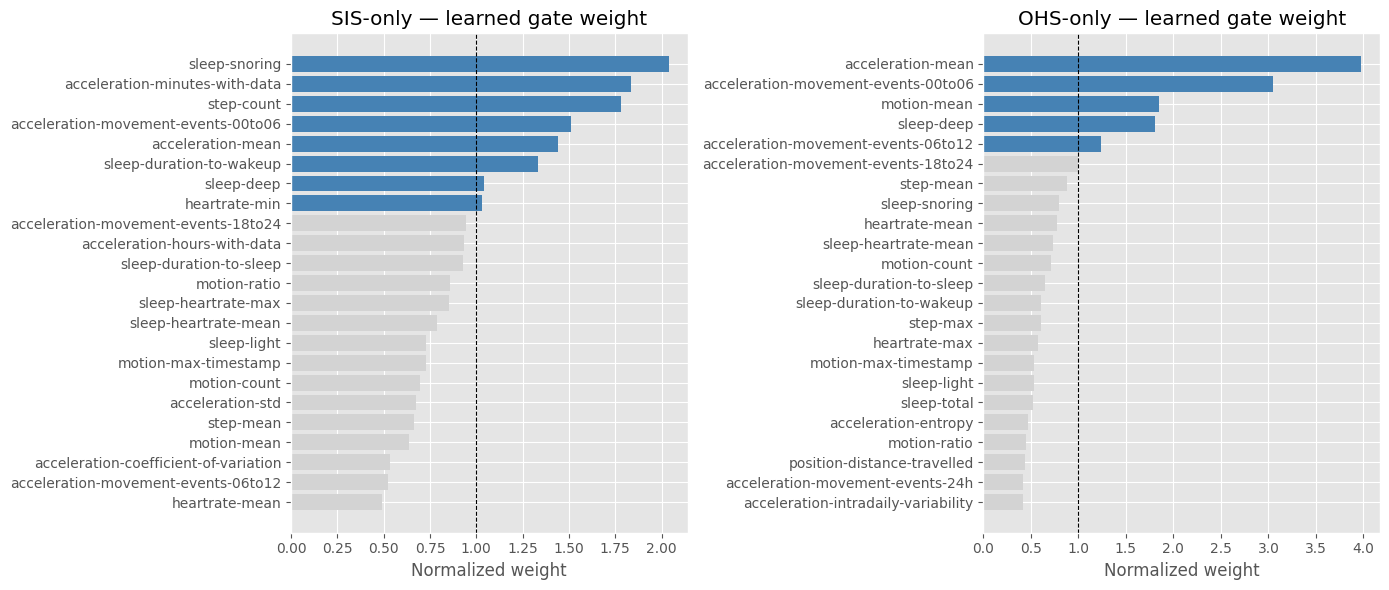


SIS-only learned gate weights:


,gate_weight
feature,
sleep-snoring,2.038
acceleration-minutes-with-data,1.837
step-count,1.780
acceleration-movement-events-00to06,1.509
acceleration-mean,1.443
sleep-duration-to-wakeup,1.332
sleep-deep,1.043
heartrate-min,1.029
acceleration-movement-events-18to24,0.946



OHS-only learned gate weights:


,gate_weight
feature,
acceleration-mean,3.976
acceleration-movement-events-00to06,3.045
motion-mean,1.849
sleep-deep,1.805
acceleration-movement-events-06to12,1.241
acceleration-movement-events-18to24,0.992
step-mean,0.877
sleep-snoring,0.794
heartrate-mean,0.772


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, artifact, task_cols in [
    (axes[0], sis_artifact, sis_sensor_cols + sis_demo_cols),
    (axes[1], ohs_artifact, ohs_sensor_cols + ohs_demo_cols),
]:
    model = artifact["model"]
    task  = artifact["task"]
    with torch.no_grad():
        gate_w = torch.nn.functional.softplus(model.feature_gate.raw).cpu().numpy()
    gate_w = gate_w / gate_w.mean()
    s = pd.Series(gate_w, index=task_cols).sort_values(ascending=False)
    colors = ["steelblue" if v > 1.0 else "lightgrey" for v in s.values]
    ax.barh(s.index[::-1], s.values[::-1], color=colors[::-1])
    ax.set_title(f"{task['name']}-only — learned gate weight")
    ax.set_xlabel("Normalized weight")
    ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

for artifact, task_cols in [
    (sis_artifact, sis_sensor_cols + sis_demo_cols),
    (ohs_artifact, ohs_sensor_cols + ohs_demo_cols),
]:
    model = artifact["model"]
    task  = artifact["task"]
    with torch.no_grad():
        gate_w = torch.nn.functional.softplus(model.feature_gate.raw).cpu().numpy()
    gate_w = gate_w / gate_w.mean()
    df = pd.DataFrame({"feature": task_cols, "gate_weight": gate_w}).set_index("feature").sort_values("gate_weight", ascending=False)
    print(f"\n{task['name']}-only learned gate weights:")
    display(df.round(3))
